# Improved CIC-IDS2017 Classical Baseline — Version 2

**Research phase:** Classical baseline development and quantum-comparison preparation  
**Task:** Binary network-intrusion classification — benign vs. malicious  
**Classical models:** Linear Support Vector Machine (SVM) and Random Forest  
**Initial split:** 70% training / 15% validation / 15% held-out test  
**Future quantum-comparison sample:** bounded sample selected only after the classical split

This notebook establishes reproducible classical reference models before later quantum or hybrid experiments.

> **Research integrity:** Do not describe results as completed until this notebook has actually been run on the improved dataset and the outputs have been reviewed.

## Why use the improved CICIDS2017 release?

The original CICIDS2017 is widely used, but later peer-reviewed analyses identified problems involving flow construction, feature extraction, and ground-truth labeling. This notebook is designed for the corrected/improved release published by the DistriNet research group.

The notebook also records provenance and file hashes so the exact local data used in an experiment can be identified later.

In [7]:
from pathlib import Path
import hashlib, json, platform, sys, time, warnings
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_DIR = Path("../data/cicids2017_improved")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_NAME = "Improved CIC-IDS2017"
DATASET_SOURCE = "https://intrusion-detection.distrinet-research.be/CNS2022/Datasets/"
DATASET_DOCUMENTATION = "https://intrusion-detection.distrinet-research.be/CNS2022/CICIDS2017.html"

CLASSICAL_MAX_ROWS = 300_000  # Set None to use the full cleaned dataset.
TREAT_ATTEMPTED_AS_BENIGN = True
QUANTUM_TRAIN_N = 700
QUANTUM_VAL_N = 150
QUANTUM_TEST_N = 150
QUANTUM_FEATURE_COUNT = 8
RUN_SOURCE_FILE_SENSITIVITY = False
print("Configuration loaded.")

Configuration loaded.


In [9]:
print(DATA_DIR.resolve())
print(DATA_DIR.exists())
print(list(DATA_DIR.glob("*.csv"))[:5])

C:\Users\MP25NN1Q\Downloads\Quantum Modeling\Exploring-Quantum-Computing---CICIDS2017-Dataset-Test\data\cicids2017_improved
False
[]


In [10]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

Current working directory:
c:\Users\MP25NN1Q\Downloads\Quantum Modeling\Exploring-Quantum-Computing---CICIDS2017-Dataset-Test\notebooks


In [11]:
from pathlib import Path

print("Expected data folder:")
print(Path("../data").resolve())

print("\nFolders/files inside data:")
print(list(Path("../data").glob("*")))

Expected data folder:
C:\Users\MP25NN1Q\Downloads\Quantum Modeling\Exploring-Quantum-Computing---CICIDS2017-Dataset-Test\data

Folders/files inside data:
[WindowsPath('../data/datacicids2017_improved'), WindowsPath('../data/README.md')]


In [12]:
DATA_DIR = Path("../data/cicids2017_improved")

print(DATA_DIR.resolve())
print(DATA_DIR.exists())
print(list(DATA_DIR.glob("*.csv"))[:10])

C:\Users\MP25NN1Q\Downloads\Quantum Modeling\Exploring-Quantum-Computing---CICIDS2017-Dataset-Test\data\cicids2017_improved
True
[WindowsPath('../data/cicids2017_improved/friday.csv'), WindowsPath('../data/cicids2017_improved/monday.csv'), WindowsPath('../data/cicids2017_improved/thursday.csv'), WindowsPath('../data/cicids2017_improved/tuesday.csv'), WindowsPath('../data/cicids2017_improved/wednesday.csv')]


## Dataset provenance and SHA-256 hashes

Place the extracted improved day-level CSV files under `data/cicids2017_improved/`. The raw dataset is not committed to GitHub. This cell computes SHA-256 hashes so the exact source files used can be documented.

In [4]:
from pathlib import Path

DATA_DIR = Path("../data/cicids2017_improved")

In [5]:
DATA_DIR.resolve()

WindowsPath('C:/Users/MP25NN1Q/Downloads/Quantum Modeling/Exploring-Quantum-Computing---CICIDS2017-Dataset-Test/data/cicids2017_improved')

In [13]:
def sha256_file(path, chunk_size=1024*1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

csv_files = sorted(DATA_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {DATA_DIR.resolve()}. Download and extract the improved CIC-IDS2017 dataset first.")

provenance = pd.DataFrame([{"file_name":p.name,"bytes":p.stat().st_size,"sha256":sha256_file(p)} for p in csv_files])
display(provenance)
provenance.to_csv(RESULTS_DIR / "dataset_file_provenance.csv", index=False)

,file_name,bytes,sha256
0,friday.csv,285188226,ebd499e6f23bd59f9cb81bec28178491b02b925fa5640a...
1,monday.csv,207875155,51fe5dc962626efb4ae70dce0303072fb780da0932822b...
2,thursday.csv,189519159,78a4d11eaf473d099e30e71ddb01e0f38218e844c0a9cd...
3,tuesday.csv,178397720,e2a0a5b631dfc6b455cc9f9a88b944110637d70a7f7417...
4,wednesday.csv,291290505,bf46c5f3c792e8817381f724511229569606918eaf07ac...


## Load and inspect the improved dataset

The notebook preserves the source filename, an original row identifier, the original class label, and any attempted-flow indicator that is available.

In [14]:
frames=[]
for path in csv_files:
    part=pd.read_csv(path, low_memory=False)
    part.columns=[str(c).strip() for c in part.columns]
    part["__source_file"]=path.name
    frames.append(part)
df=pd.concat(frames, ignore_index=True)
df["__row_id"]=np.arange(len(df), dtype=np.int64)
print(f"Loaded {len(csv_files)} files")
print("Raw shape:", df.shape)
print(df.columns.tolist())

Loaded 5 files
Raw shape: (2099976, 93)
['id', 'Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd RST Flags', 'Bwd RST Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag

In [15]:
print("Unique Label values:")
print(df["Label"].value_counts(dropna=False))

print("\nUnique Attempted Category values:")
print(df["Attempted Category"].value_counts(dropna=False))

Unique Label values:
Label
BENIGN                                    1582566
Portscan                                   159066
DoS Hulk                                   158468
DDoS                                        95144
Infiltration - Portscan                     71767
DoS GoldenEye                                7567
Botnet - Attempted                           4067
FTP-Patator                                  3972
DoS Slowloris                                3859
DoS Slowhttptest - Attempted                 3368
SSH-Patator                                  2961
DoS Slowloris - Attempted                    1847
DoS Slowhttptest                             1740
Web Attack - Brute Force - Attempted         1292
Botnet                                        736
Web Attack - XSS - Attempted                  655
DoS Hulk - Attempted                          581
DoS GoldenEye - Attempted                      80
Web Attack - Brute Force                       73
Infiltration - Attempte

In [19]:
attempted = df[df["Attempted Category"] != -1]

print("Number of attempted-category rows:", len(attempted))

print("\nLabels among attempted-category rows:")
print(attempted["Label"].value_counts())

print("\nAttempted Category by Label:")
print(
    pd.crosstab(
        attempted["Label"],
        attempted["Attempted Category"]
    )
)

Number of attempted-category rows: 11979

Labels among attempted-category rows:
Label
Botnet - Attempted                        4067
DoS Slowhttptest - Attempted              3368
DoS Slowloris - Attempted                 1847
Web Attack - Brute Force - Attempted      1292
Web Attack - XSS - Attempted               655
DoS Hulk - Attempted                       581
DoS GoldenEye - Attempted                   80
Infiltration - Attempted                    45
SSH-Patator - Attempted                     27
FTP-Patator - Attempted                     12
Web Attack - SQL Injection - Attempted       5
Name: count, dtype: int64

Attempted Category by Label:
Attempted Category                         0     1  2   3   4    5     6
Label                                                                   
Botnet - Attempted                         0  4067  0   0   0    0     0
DoS GoldenEye - Attempted                 80     0  0   0   0    0     0
DoS Hulk - Attempted                     579     

In [20]:
attempted = df[df["Attempted Category"] != -1]

print("Number of attempted-category rows:", len(attempted))

print("\nLabels among attempted-category rows:")
print(attempted["Label"].value_counts())

print("\nAttempted Category by Label:")
print(
    pd.crosstab(
        attempted["Label"],
        attempted["Attempted Category"]
    )
)

Number of attempted-category rows: 11979

Labels among attempted-category rows:
Label
Botnet - Attempted                        4067
DoS Slowhttptest - Attempted              3368
DoS Slowloris - Attempted                 1847
Web Attack - Brute Force - Attempted      1292
Web Attack - XSS - Attempted               655
DoS Hulk - Attempted                       581
DoS GoldenEye - Attempted                   80
Infiltration - Attempted                    45
SSH-Patator - Attempted                     27
FTP-Patator - Attempted                     12
Web Attack - SQL Injection - Attempted       5
Name: count, dtype: int64

Attempted Category by Label:
Attempted Category                         0     1  2   3   4    5     6
Label                                                                   
Botnet - Attempted                         0  4067  0   0   0    0     0
DoS GoldenEye - Attempted                 80     0  0   0   0    0     0
DoS Hulk - Attempted                     579     

In [16]:
df["original_label"] = df["Label"].copy()
df["original_attempted_category"] = df["Attempted Category"].copy()

print("Original labels preserved.")

Original labels preserved.


In [17]:
print("Dataset shape:", df.shape)

print("\nMissing values in key columns:")
print(df[["Label", "Attempted Category"]].isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape: (2099976, 95)

Missing values in key columns:
Label                 0
Attempted Category    0
dtype: int64

Duplicate rows:
0


In [18]:
print("Rows by source file:")
print(df["__source_file"].value_counts())

Rows by source file:
__source_file
friday.csv       547557
wednesday.csv    496641
monday.csv       371624
thursday.csv     362076
tuesday.csv      322078
Name: count, dtype: int64


In [21]:
df["original_label"] = df["Label"].copy()
df["original_attempted_category"] = df["Attempted Category"].copy()

print("Original labels preserved.")

Original labels preserved.


In [22]:
df["is_attempted"] = df["Attempted Category"] != -1

print("Attempted records:", df["is_attempted"].sum())
print("Non-attempted records:", (~df["is_attempted"]).sum())

Attempted records: 11979
Non-attempted records: 2087997


In [23]:
print(
    df.loc[
        df["Label"].astype(str).str.lower().str.contains("benign"),
        "Label"
    ].value_counts()
)

Label
BENIGN    1582566
Name: count, dtype: int64


In [24]:
df["label_normalized"] = (
    df["Label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

## Construct the binary target transparently 

Initial target: benign = 0, malicious = 1.

The improved release distinguishes some flows as attempted attacks. The starter configuration treats attempted flows as benign for the initial binary task because the expected malicious behavior may not have completed. This choice is recorded and can be revisited later.

In [26]:
is_benign = df["label_normalized"].eq("benign")
is_attempted = df["is_attempted"]

if TREAT_ATTEMPTED_AS_BENIGN:
    df["binary_target"] = np.where(
        is_benign | is_attempted,
        0,
        1
    )
else:
    df["binary_target"] = np.where(
        is_benign,
        0,
        1
    )

print("Binary target created.")

Binary target created.


In [27]:
print("Binary target distribution:")
print(df["binary_target"].value_counts())

print("\nBinary target percentages:")
print(df["binary_target"].value_counts(normalize=True) * 100)

Binary target distribution:
binary_target
0    1594545
1     505431
Name: count, dtype: int64

Binary target percentages:
binary_target
0    75.931582
1    24.068418
Name: proportion, dtype: float64


In [28]:
print(
    df.loc[df["is_attempted"], "binary_target"]
    .value_counts()
)

binary_target
0    11979
Name: count, dtype: int64


In [29]:
print(
    pd.crosstab(
        df["original_label"],
        df["binary_target"]
    )
)

binary_target                                 0       1
original_label                                         
BENIGN                                  1582566       0
Botnet                                        0     736
Botnet - Attempted                         4067       0
DDoS                                          0   95144
DoS GoldenEye                                 0    7567
DoS GoldenEye - Attempted                    80       0
DoS Hulk                                      0  158468
DoS Hulk - Attempted                        581       0
DoS Slowhttptest                              0    1740
DoS Slowhttptest - Attempted               3368       0
DoS Slowloris                                 0    3859
DoS Slowloris - Attempted                  1847       0
FTP-Patator                                   0    3972
FTP-Patator - Attempted                      12       0
Heartbleed                                    0      11
Infiltration                                  0 

In [30]:
attempted_summary = (
    df.loc[df["is_attempted"]]
      .groupby(
          ["original_label", "original_attempted_category"],
          dropna=False
      )
      .size()
      .reset_index(name="row_count")
)

attempted_summary.to_csv(
    RESULTS_DIR / "attempted_flow_treatment_summary.csv",
    index=False
)

print("Saved attempted-flow treatment summary.")

Saved attempted-flow treatment summary.


In [31]:
TREAT_ATTEMPTED_AS_BENIGN = True

## Build a leakage-aware numeric feature matrix

Direct identifiers and metadata are excluded where present, including flow IDs, IP addresses, timestamps, source-file metadata, labels, and ports. Ports are conservatively excluded in this starter because they can encode scenario-specific shortcuts in benchmark datasets.

In [35]:
LABEL_COL = "Label"
ATTEMPTED_COL = "Attempted Category"

print("Label column:", LABEL_COL)
print("Attempted-flow column:", ATTEMPTED_COL)

Label column: Label
Attempted-flow column: Attempted Category


In [37]:
print("binary_target" in df.columns)

True


In [38]:
def normalize_name(name):
    return "".join(
        ch.lower()
        for ch in str(name).strip()
        if ch.isalnum()
    )

print("normalize_name function loaded.")

normalize_name function loaded.


In [39]:
print(normalize_name("Attempted Category"))
print(normalize_name("Src IP"))
print(normalize_name("Flow ID"))

attemptedcategory
srcip
flowid


In [41]:
meta_all = df[
    ["__row_id", "__source_file", "original_label"]
].copy()

In [42]:
print([c for c in df.columns if "original" in c.lower()])

['original_label', 'original_attempted_category']


In [43]:
# Columns that should not be used as predictive model features
DROP_NORMALIZED = {
    "label",
    "class",
    "attacklabel",
    "flowid",
    "sourceip",
    "srcip",
    "destinationip",
    "dstip",
    "timestamp",
    "datetime"
}

# Internal / metadata columns that must not be model features
drop_cols = {
    LABEL_COL,
    "__source_file",
    "__row_id",
    "original_label",
    "original_attempted_category",
    "binary_target",
    "label_normalized",
    "is_attempted"
}

# Exclude the attempted-category column from the feature matrix
if ATTEMPTED_COL is not None:
    drop_cols.add(ATTEMPTED_COL)

# Find additional columns whose normalized names match known leakage fields
for c in df.columns:
    if normalize_name(c) in DROP_NORMALIZED:
        drop_cols.add(c)

# Everything else becomes a candidate model feature
feature_cols = [
    c for c in df.columns
    if c not in drop_cols
]

# Convert candidate features to numeric values
X_all = (
    df[feature_cols]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

# Remove columns that contain no usable numeric values
all_nan = X_all.columns[X_all.isna().all()].tolist()

if all_nan:
    X_all = X_all.drop(columns=all_nan)

# Binary prediction target
y_all = df["binary_target"].copy()

# Metadata retained separately for auditing, but NOT used by the model
meta_all = df[
    ["__row_id", "__source_file", "original_label"]
].copy()

print("Numeric feature matrix:", X_all.shape)
print("Excluded columns:", sorted(drop_cols))
print("All-NaN columns removed:", all_nan)
print("Target distribution:")
print(y_all.value_counts())

Numeric feature matrix: (2099976, 85)
Excluded columns: ['Attempted Category', 'Dst IP', 'Flow ID', 'Label', 'Src IP', 'Timestamp', '__row_id', '__source_file', 'binary_target', 'is_attempted', 'label_normalized', 'original_attempted_category', 'original_label']
All-NaN columns removed: []
Target distribution:
binary_target
0    1594545
1     505431
Name: count, dtype: int64


In [44]:
# Missing-value audit of the model feature matrix

missing_counts = X_all.isna().sum().sort_values(ascending=False)

print("Total missing feature values:")
print(int(missing_counts.sum()))

print("\nRows containing at least one missing feature:")
print(int(X_all.isna().any(axis=1).sum()))

print("\nTop 20 features with missing values:")
print(missing_counts[missing_counts > 0].head(20))

print("\nNumber of features containing missing values:")
print(int((missing_counts > 0).sum()))

Total missing feature values:
10

Rows containing at least one missing feature:
5

Top 20 features with missing values:
Flow Bytes/s      5
Flow Packets/s    5
dtype: int64

Number of features containing missing values:
2


In [45]:
# Duplicate audit using model features + target

duplicate_check = X_all.copy()
duplicate_check["binary_target"] = y_all.to_numpy()

duplicate_mask = duplicate_check.duplicated(keep=False)

print("Rows involved in exact feature/target duplicates:")
print(int(duplicate_mask.sum()))

print("\nUnique duplicate rows beyond the first occurrence:")
print(int(duplicate_check.duplicated().sum()))

Rows involved in exact feature/target duplicates:
6

Unique duplicate rows beyond the first occurrence:
3


In [46]:
# Check whether identical feature vectors ever have different labels

feature_hash = pd.util.hash_pandas_object(X_all, index=False)

label_per_feature = (
    pd.DataFrame({
        "feature_hash": feature_hash,
        "target": y_all.to_numpy()
    })
    .groupby("feature_hash")["target"]
    .nunique()
)

conflicting_feature_sets = (label_per_feature > 1).sum()

print("Identical feature sets associated with more than one target label:")
print(int(conflicting_feature_sets))

Identical feature sets associated with more than one target label:
0


In [47]:
print("Rows by source file:")
print(meta_all["__source_file"].value_counts())

print("\nTarget distribution by source file:")
source_target = pd.crosstab(
    meta_all["__source_file"],
    y_all,
    margins=True
)

print(source_target)

Rows by source file:
__source_file
friday.csv       547557
wednesday.csv    496641
monday.csv       371624
thursday.csv     362076
tuesday.csv      322078
Name: count, dtype: int64

Target distribution by source file:
binary_target        0       1      All
__source_file                          
friday.csv      292611  254946   547557
monday.csv      371624       0   371624
thursday.csv    290169   71907   362076
tuesday.csv     315145    6933   322078
wednesday.csv   324996  171645   496641
All            1594545  505431  2099976


In [48]:
feature_audit = pd.DataFrame({
    "feature": list(X_all.columns)
})

feature_audit.to_csv(
    RESULTS_DIR / "initial_numeric_feature_list.csv",
    index=False
)

excluded_audit = pd.DataFrame({
    "excluded_column": sorted(drop_cols)
})

excluded_audit.to_csv(
    RESULTS_DIR / "excluded_columns_leakage_control.csv",
    index=False
)

print("Saved feature and leakage-control audit files.")

Saved feature and leakage-control audit files.


In [49]:
#Running conflicting label check
feature_hash = pd.util.hash_pandas_object(X_all, index=False)

label_per_feature = (
    pd.DataFrame({
        "feature_hash": feature_hash,
        "target": y_all.to_numpy()
    })
    .groupby("feature_hash")["target"]
    .nunique()
)

conflicting_feature_sets = (label_per_feature > 1).sum()

print(
    "Identical feature sets associated with more than one target label:"
)
print(int(conflicting_feature_sets))

Identical feature sets associated with more than one target label:
0


In [53]:
duplicate_check = X_all.copy()
duplicate_check["binary_target"] = y_all.to_numpy()

keep_mask = ~duplicate_check.duplicated(keep="first")

X_clean = X_all.loc[keep_mask].reset_index(drop=True)
y_clean = y_all.loc[keep_mask].reset_index(drop=True)
meta_clean = meta_all.loc[keep_mask].reset_index(drop=True)

print("Before duplicate removal:", len(X_all))
print("After duplicate removal:", len(X_clean))
print("Rows removed:", len(X_all) - len(X_clean))

Before duplicate removal: 2099976
After duplicate removal: 2099973
Rows removed: 3


## Optional documented cap for the classical starter run

Set `CLASSICAL_MAX_ROWS = None` to use the full cleaned dataset. The default starter value applies a stratified cap to keep the first run practical on ordinary hardware. If used, the cap is recorded in metadata and should be disclosed.

In [54]:
# Optional documented cap for the initial classical starter run

if CLASSICAL_MAX_ROWS is not None and len(X_clean) > CLASSICAL_MAX_ROWS:

    selected_idx, _ = train_test_split(
        np.arange(len(X_clean)),
        train_size=CLASSICAL_MAX_ROWS,
        stratify=y_clean,
        random_state=RANDOM_STATE
    )

    selected_idx = np.sort(selected_idx)

    X = X_clean.iloc[selected_idx].reset_index(drop=True)
    y = y_clean.iloc[selected_idx].reset_index(drop=True)
    meta = meta_clean.iloc[selected_idx].reset_index(drop=True)

else:
    X = X_clean.reset_index(drop=True)
    y = y_clean.reset_index(drop=True)
    meta = meta_clean.reset_index(drop=True)

print("Full cleaned dataset:", X_clean.shape)
print("Working classical dataset:", X.shape)

print("\nWorking target counts:")
print(y.value_counts())

print("\nWorking target proportions:")
print(y.value_counts(normalize=True).rename("proportion"))

Full cleaned dataset: (2099973, 85)
Working classical dataset: (300000, 85)

Working target counts:
binary_target
0    227795
1     72205
Name: count, dtype: int64

Working target proportions:
binary_target
0    0.759317
1    0.240683
Name: proportion, dtype: float64


In [55]:
starter_sample_manifest = meta.copy()

starter_sample_manifest["binary_target"] = y.to_numpy()

starter_sample_manifest.to_csv(
    RESULTS_DIR / "classical_starter_sample_manifest.csv",
    index=False
)

print(
    "Saved:",
    RESULTS_DIR / "classical_starter_sample_manifest.csv"
)

Saved: ..\results\classical_starter_sample_manifest.csv


## Create reproducible 70/15/15 classical partitions

The initial design uses 70% training, 15% validation, and 15% held-out test, stratified by the binary target. A later temporal or source-file sensitivity analysis should be performed before making strong generalization claims.

In [56]:
idx = np.arange(len(X))

train_idx, temp_idx = train_test_split(
    idx,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=y.iloc[temp_idx],
    random_state=RANDOM_STATE
)

def take(indices):
    return (
        X.iloc[indices].copy(),
        y.iloc[indices].copy(),
        meta.iloc[indices].copy()
    )

X_train, y_train, meta_train = take(train_idx)
X_val, y_val, meta_val = take(val_idx)
X_test, y_test, meta_test = take(test_idx)

split_summary = pd.DataFrame(
    {
        "rows": [
            len(X_train),
            len(X_val),
            len(X_test)
        ],
        "fraction": [
            len(X_train) / len(X),
            len(X_val) / len(X),
            len(X_test) / len(X)
        ],
        "malicious_rate": [
            y_train.mean(),
            y_val.mean(),
            y_test.mean()
        ]
    },
    index=["train", "validation", "test"]
)

display(split_summary)

,rows,fraction,malicious_rate
train,210000,0.70,0.240686
validation,45000,0.15,0.240689
test,45000,0.15,0.240667


In [57]:
train_manifest = meta_train.copy()
train_manifest["split"] = "train"
train_manifest["binary_target"] = y_train.to_numpy()

val_manifest = meta_val.copy()
val_manifest["split"] = "validation"
val_manifest["binary_target"] = y_val.to_numpy()

test_manifest = meta_test.copy()
test_manifest["split"] = "test"
test_manifest["binary_target"] = y_test.to_numpy()

split_manifest = pd.concat(
    [
        train_manifest,
        val_manifest,
        test_manifest
    ],
    ignore_index=True
)

split_manifest.to_csv(
    RESULTS_DIR / "classical_partition_manifest.csv",
    index=False
)

print("Saved classical partition manifest.")

Saved classical partition manifest.


In [58]:
split_summary.to_csv(
    RESULTS_DIR / "classical_split_summary.csv"
)

print("Saved classical split summary.")

Saved classical split summary.


In [59]:
print("Training missing values:", int(X_train.isna().sum().sum()))
print("Validation missing values:", int(X_val.isna().sum().sum()))
print("Test missing values:", int(X_test.isna().sum().sum()))

Training missing values: 2
Validation missing values: 0
Test missing values: 0


## Source-file distribution audit

Random stratification can place records from the same collection day in multiple partitions. This audit reports source-file representation so possible day/source artifacts are visible.

In [60]:
def source_distribution(meta_part,name): return meta_part["__source_file"].value_counts(normalize=True).rename(name)
source_audit=pd.concat([source_distribution(meta_train,"train"),source_distribution(meta_val,"validation"),source_distribution(meta_test,"test")],axis=1).fillna(0)
display(source_audit)
source_audit.to_csv(RESULTS_DIR/"source_file_distribution.csv")

,train,validation,test
__source_file,,,
friday.csv,0.259771,0.262267,0.256956
wednesday.csv,0.236224,0.236067,0.234800
monday.csv,0.175995,0.175578,0.178133
thursday.csv,0.172795,0.172200,0.174689
tuesday.csv,0.155214,0.153889,0.155422


## Create and Train SVM Pipeline

In [61]:
def evaluate_model(name, model, X_eval, y_eval, train_seconds=None):
    start = time.perf_counter()

    pred = model.predict(X_eval)

    infer = time.perf_counter() - start

    tn, fp, fn, tp = confusion_matrix(
        y_eval,
        pred,
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) else np.nan

    if hasattr(model, "decision_function"):
        score = model.decision_function(X_eval)
    elif hasattr(model, "predict_proba"):
        score = model.predict_proba(X_eval)[:, 1]
    else:
        score = None

    auc = (
        roc_auc_score(y_eval, score)
        if score is not None
        else np.nan
    )

    return {
        "model": name,
        "accuracy": accuracy_score(y_eval, pred),
        "precision": precision_score(
            y_eval,
            pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_eval,
            pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_eval,
            pred,
            zero_division=0
        ),
        "false_positive_rate": fpr,
        "roc_auc": auc,
        "train_seconds": train_seconds,
        "inference_seconds": infer,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }

In [62]:
svm_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        max_iter=10000
    ))
])

print("SVM pipeline created.")

SVM pipeline created.


In [63]:
svm_start = time.perf_counter()

svm_pipeline.fit(
    X_train,
    y_train
)

svm_training_time = (
    time.perf_counter() - svm_start
)

print(
    f"SVM training completed in "
    f"{svm_training_time:.2f} seconds."
)

SVM training completed in 69.82 seconds.


## Classical model evaluation function

In [64]:
svm_val_results = evaluate_model(
    "Linear SVM",
    svm_pipeline,
    X_val,
    y_val,
    train_seconds=svm_training_time
)

svm_val_results

{'model': 'Linear SVM',
 'accuracy': 0.9918444444444444,
 'precision': 0.9758093852309931,
 'recall': 0.9906749145969901,
 'f1': 0.9831859623402208,
 'false_positive_rate': np.float64(0.007784834206444438),
 'roc_auc': 0.9987923891066384,
 'train_seconds': 69.81997479998972,
 'inference_seconds': 0.14542139999684878,
 'tn': 33903,
 'fp': 266,
 'fn': 101,
 'tp': 10730}

In [65]:
svm_results_df = pd.DataFrame([svm_val_results])

display(svm_results_df)

svm_results_df.to_csv(
    RESULTS_DIR / "svm_validation_results.csv",
    index=False
)

print("Saved SVM validation results.")

,model,accuracy,precision,recall,f1,false_positive_rate,roc_auc,train_seconds,inference_seconds,tn,fp,fn,tp
0,Linear SVM,0.991844,0.975809,0.990675,0.983186,0.007785,0.998792,69.819975,0.145421,33903,266,101,10730


Saved SVM validation results.


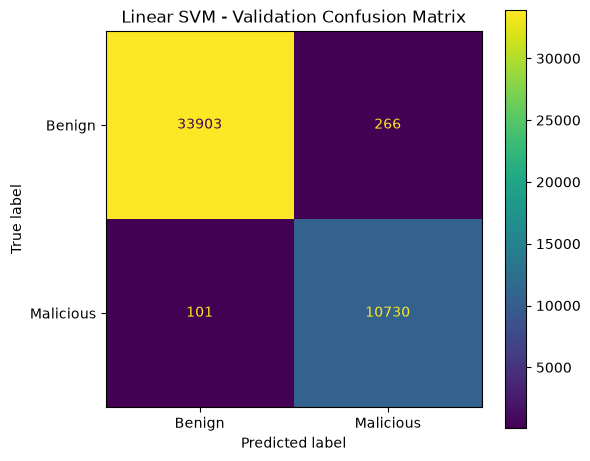

In [66]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_val,
        svm_pipeline.predict(X_val),
        labels=[0, 1]
    ),
    display_labels=["Benign", "Malicious"]
).plot(
    ax=ax,
    values_format="d"
)

ax.set_title("Linear SVM - Validation Confusion Matrix")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "svm_validation_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Classical Starter Sample Baseline

These results are the larger classical reference. They are not yet the direct fair comparator for a future quantum kernel, because the quantum experiment will use a much smaller bounded sample.

In [67]:
rf_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

start = time.perf_counter()

rf_model.fit(
    X_train,
    y_train
)

rf_train_seconds = (
    time.perf_counter() - start
)

print(
    f"Random Forest training completed in "
    f"{rf_train_seconds:.2f} seconds."
)

Random Forest training completed in 79.41 seconds.


In [68]:
rf_val_results = evaluate_model(
    "Random Forest",
    rf_model,
    X_val,
    y_val,
    rf_train_seconds
)

rf_val_results

{'model': 'Random Forest',
 'accuracy': 0.9998222222222222,
 'precision': 0.9997229661095207,
 'recall': 0.9995383621087619,
 'f1': 0.9996306555863342,
 'false_positive_rate': np.float64(8.779888202756885e-05),
 'roc_auc': 0.9999998743529988,
 'train_seconds': 79.41052840001066,
 'inference_seconds': 0.41856810002354905,
 'tn': 34166,
 'fp': 3,
 'fn': 5,
 'tp': 10826}

In [69]:
svm_val_results

{'model': 'Linear SVM',
 'accuracy': 0.9918444444444444,
 'precision': 0.9758093852309931,
 'recall': 0.9906749145969901,
 'f1': 0.9831859623402208,
 'false_positive_rate': np.float64(0.007784834206444438),
 'roc_auc': 0.9987923891066384,
 'train_seconds': 69.81997479998972,
 'inference_seconds': 0.14542139999684878,
 'tn': 33903,
 'fp': 266,
 'fn': 101,
 'tp': 10730}

In [70]:
val_results = pd.DataFrame([
    svm_val_results,
    rf_val_results
]).set_index("model")

display(
    val_results.round(4)
)

,accuracy,precision,recall,f1,false_positive_rate,roc_auc,train_seconds,inference_seconds,tn,fp,fn,tp
model,,,,,,,,,,,,
Linear SVM,0.9918,0.9758,0.9907,0.9832,0.0078,0.9988,69.8200,0.1454,33903,266,101,10730
Random Forest,0.9998,0.9997,0.9995,0.9996,0.0001,1.0000,79.4105,0.4186,34166,3,5,10826


In [71]:
val_results.to_csv(
    RESULTS_DIR / "classical_validation_comparison.csv"
)

print("Saved classical validation comparison.")

Saved classical validation comparison.


In [72]:
rf_results_df = pd.DataFrame([
    rf_val_results
])

rf_results_df.to_csv(
    RESULTS_DIR / "random_forest_validation_results.csv",
    index=False
)

print("Saved Random Forest validation results.")

Saved Random Forest validation results.


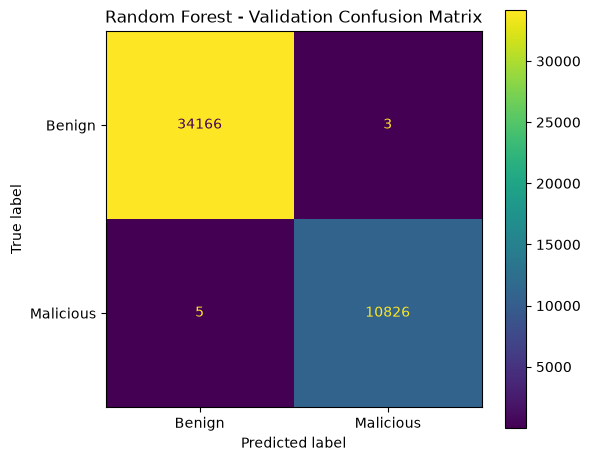

In [73]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_val,
        rf_model.predict(X_val),
        labels=[0, 1]
    ),
    display_labels=["Benign", "Malicious"]
).plot(
    ax=ax,
    values_format="d"
)

ax.set_title("Random Forest - Validation Confusion Matrix")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "random_forest_validation_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Held-out classical test evaluation

Use the held-out test set only after the baseline methodology is settled.

In [ ]:
test_results=pd.DataFrame([evaluate_model("Linear SVM",svm_model,X_test,y_test,svm_train_seconds),evaluate_model("Random Forest",rf_model,X_test,y_test,rf_train_seconds)]).set_index("model")
display(test_results.round(4))
test_results.to_csv(RESULTS_DIR/"classical_baseline_results.csv")

## 13. Confusion matrices

In [ ]:
for model_name,model in [("Linear SVM",svm_model),("Random Forest",rf_model)]:
    pred=model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test,pred,display_labels=["Benign","Malicious"],values_format="d")
    plt.title(f"{model_name} — Held-Out Test Set")
    plt.show()

## 14. Prepare a bounded future quantum-comparison subset

The full dataset is **not** intended to be sent into a quantum-kernel simulator. Instead, a bounded sample is selected separately within the already-created train, validation, and held-out test partitions. The default starter target is 700/150/150. The exact number may be adjusted after pilot measurements of memory use and execution time.

In [ ]:
def stratified_bounded_sample(Xp,yp,mp,n,seed):
    n=min(n,len(Xp))
    if n==len(Xp): chosen=np.arange(len(Xp))
    else: chosen,_=train_test_split(np.arange(len(Xp)),train_size=n,stratify=yp,random_state=seed)
    chosen=np.sort(chosen)
    return Xp.iloc[chosen].reset_index(drop=True), yp.iloc[chosen].reset_index(drop=True), mp.iloc[chosen].reset_index(drop=True)
X_qtrain,y_qtrain,meta_qtrain=stratified_bounded_sample(X_train.reset_index(drop=True),y_train.reset_index(drop=True),meta_train.reset_index(drop=True),QUANTUM_TRAIN_N,RANDOM_STATE+1)
X_qval,y_qval,meta_qval=stratified_bounded_sample(X_val.reset_index(drop=True),y_val.reset_index(drop=True),meta_val.reset_index(drop=True),QUANTUM_VAL_N,RANDOM_STATE+2)
X_qtest,y_qtest,meta_qtest=stratified_bounded_sample(X_test.reset_index(drop=True),y_test.reset_index(drop=True),meta_test.reset_index(drop=True),QUANTUM_TEST_N,RANDOM_STATE+3)
quantum_subset_summary=pd.DataFrame({"rows":[len(X_qtrain),len(X_qval),len(X_qtest)],"malicious_rate":[y_qtrain.mean(),y_qval.mean(),y_qtest.mean()]},index=["train","validation","test"])
display(quantum_subset_summary)

## 15. Save a quantum-subset manifest without raw features

The manifest contains only original row identifier, source file, original label, binary target, and partition. It does not redistribute the raw feature rows.

In [ ]:
def manifest(mp,yp,partition):
    out=mp.copy(); out["target"]=yp.to_numpy(); out["partition"]=partition; return out
q_manifest=pd.concat([manifest(meta_qtrain,y_qtrain,"train"),manifest(meta_qval,y_qval,"validation"),manifest(meta_qtest,y_qtest,"test")],ignore_index=True)
display(q_manifest.head())
q_manifest.to_csv(RESULTS_DIR/"quantum_subset_manifest.csv",index=False)

## 16. Select a reduced feature set using training data only

A future quantum-kernel experiment should use a small feature representation. This starter uses mutual information as one transparent feature-ranking method. Ranking is performed on the bounded quantum training subset only so validation/test data do not influence feature selection.

In [ ]:
q_imputer=SimpleImputer(strategy="median")
X_qtrain_imp=q_imputer.fit_transform(X_qtrain)
mi=mutual_info_classif(X_qtrain_imp,y_qtrain,random_state=RANDOM_STATE)
mi_table=pd.DataFrame({"feature":X_qtrain.columns,"mutual_information":mi}).sort_values("mutual_information",ascending=False)
selected_features=mi_table.head(min(QUANTUM_FEATURE_COUNT,len(mi_table)))["feature"].tolist()
display(mi_table.head(20))
print("Selected features:", selected_features)
with open(RESULTS_DIR/"quantum_candidate_features.json","w",encoding="utf-8") as f:
    json.dump({"method":"mutual_info_classif","fit_partition":"bounded quantum-comparison training subset only","feature_count":len(selected_features),"features":selected_features},f,indent=2)

## 17. Same-sample, same-feature classical comparator

This is the classical result that should eventually be compared directly with a quantum-kernel model. It uses the same bounded observations, reduced feature set, and train/validation/test boundaries.

In [ ]:
Xq_tr=X_qtrain[selected_features]; Xq_te=X_qtest[selected_features]
svm_qcomp=Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler()),("svm",LinearSVC(C=1.0,class_weight="balanced",random_state=RANDOM_STATE,max_iter=10000))])
start=time.perf_counter(); svm_qcomp.fit(Xq_tr,y_qtrain); svm_q_train_seconds=time.perf_counter()-start
rf_qcomp=Pipeline([("imputer",SimpleImputer(strategy="median")),("rf",RandomForestClassifier(n_estimators=300,class_weight="balanced_subsample",random_state=RANDOM_STATE,n_jobs=-1))])
start=time.perf_counter(); rf_qcomp.fit(Xq_tr,y_qtrain); rf_q_train_seconds=time.perf_counter()-start
qcomp_results=pd.DataFrame([evaluate_model("Linear SVM — bounded/reduced",svm_qcomp,Xq_te,y_qtest,svm_q_train_seconds),evaluate_model("Random Forest — bounded/reduced",rf_qcomp,Xq_te,y_qtest,rf_q_train_seconds)]).set_index("model")
display(qcomp_results.round(4))
qcomp_results.to_csv(RESULTS_DIR/"bounded_reduced_classical_comparator.csv")

## 18. Optional source-file/day holdout sensitivity scaffold

A random 70/15/15 split is useful for a reproducible baseline, but it does not fully test whether the models generalize across different collection days. This optional scaffold separates entire source files. Because there are few source files, exact proportions may differ from 70/15/15.

In [ ]:
if RUN_SOURCE_FILE_SENSITIVITY:
    groups=meta["__source_file"].to_numpy(); idx_all=np.arange(len(X))
    gss1=GroupShuffleSplit(n_splits=1,train_size=0.70,random_state=RANDOM_STATE)
    gtrain_idx,grem_idx=next(gss1.split(idx_all,y,groups=groups))
    rem_groups=groups[grem_idx]
    gss2=GroupShuffleSplit(n_splits=1,train_size=0.50,random_state=RANDOM_STATE+1)
    gval_rel,gtest_rel=next(gss2.split(grem_idx,y.iloc[grem_idx],groups=rem_groups))
    gval_idx=grem_idx[gval_rel]; gtest_idx=grem_idx[gtest_rel]
    print("Train files:",sorted(meta.iloc[gtrain_idx]["__source_file"].unique()))
    print("Validation files:",sorted(meta.iloc[gval_idx]["__source_file"].unique()))
    print("Test files:",sorted(meta.iloc[gtest_idx]["__source_file"].unique()))
else:
    print("Source-file sensitivity analysis is disabled by default.")

## 19. Save run metadata

The metadata file provides a machine-readable record of the experiment configuration. Review it before committing generated results.

In [ ]:
run_metadata={"dataset_name":DATASET_NAME,"dataset_source":DATASET_SOURCE,"dataset_documentation":DATASET_DOCUMENTATION,"random_state":RANDOM_STATE,"classical_max_rows":CLASSICAL_MAX_ROWS,"treat_attempted_as_benign":TREAT_ATTEMPTED_AS_BENIGN,"raw_loaded_rows":int(len(df)),"working_rows":int(len(X)),"working_feature_count":int(X.shape[1]),"train_rows":int(len(X_train)),"validation_rows":int(len(X_val)),"test_rows":int(len(X_test)),"quantum_train_target":QUANTUM_TRAIN_N,"quantum_validation_target":QUANTUM_VAL_N,"quantum_test_target":QUANTUM_TEST_N,"quantum_feature_count":int(len(selected_features)),"selected_quantum_candidate_features":selected_features,"software":{"python":sys.version,"platform":platform.platform(),"pandas":pd.__version__,"numpy":np.__version__,"scikit_learn":sklearn.__version__,"matplotlib":matplotlib.__version__}}
with open(RESULTS_DIR/"run_metadata.json","w",encoding="utf-8") as f: json.dump(run_metadata,f,indent=2)
print(json.dumps(run_metadata,indent=2))

## 20. Interpretation template

Complete this section only after the notebook runs successfully.

### Dataset provenance
- Improved CIC-IDS2017 release/source:
- Files used:
- SHA-256 manifest reviewed:
- Treatment of attempted flows:

### Classical baseline
- Full/working rows:
- Sampling cap used, if any:
- Feature count:
- Train/validation/test sizes:
- Linear SVM metrics:
- Random Forest metrics:

### Bounded quantum-comparison preparation
- Bounded train/validation/test sizes:
- Reduced feature count:
- Selected feature names:
- Same-sample SVM metrics:
- Same-sample Random Forest metrics:

### Leakage and robustness notes
- Source-file distribution across random partitions:
- Any obvious source/day imbalance:
- Whether source-file/day holdout sensitivity analysis was run:
- Any concerns about temporal proximity or benchmark artifacts:

### Required limitations
Discuss at minimum:
- corrected/improved CIC-IDS2017 is still a benchmark rather than live enterprise telemetry;
- binary relabeling simplifies the original multiclass problem;
- a stratified random split may not prove temporal generalization;
- a bounded quantum sample trades representativeness for computational feasibility;
- simulator feasibility does not equal physical quantum-hardware feasibility;
- none of these results demonstrate live real-time quantum threat detection.